In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
# =========================
# 1. Import Libraries
# =========================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import seaborn as sns
from collections import Counter
import hashlib

# =========================
# 2. Set Dataset Path
# =========================
DATASET_PATH = "//kaggle/input/datasets/niwash2062/brain-tumor/brain_tumor_dataset_final"  # change path

# =========================
# 3. Load Dataset Paths
# =========================
image_paths = []
labels = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)
            label = os.path.basename(root)
            image_paths.append(path)
            labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total Images:", len(df))
print(df.head())

Total Images: 9469
                                          image_path      label
0  //kaggle/input/datasets/niwash2062/brain-tumor...  pituitary
1  //kaggle/input/datasets/niwash2062/brain-tumor...  pituitary
2  //kaggle/input/datasets/niwash2062/brain-tumor...  pituitary
3  //kaggle/input/datasets/niwash2062/brain-tumor...  pituitary
4  //kaggle/input/datasets/niwash2062/brain-tumor...  pituitary


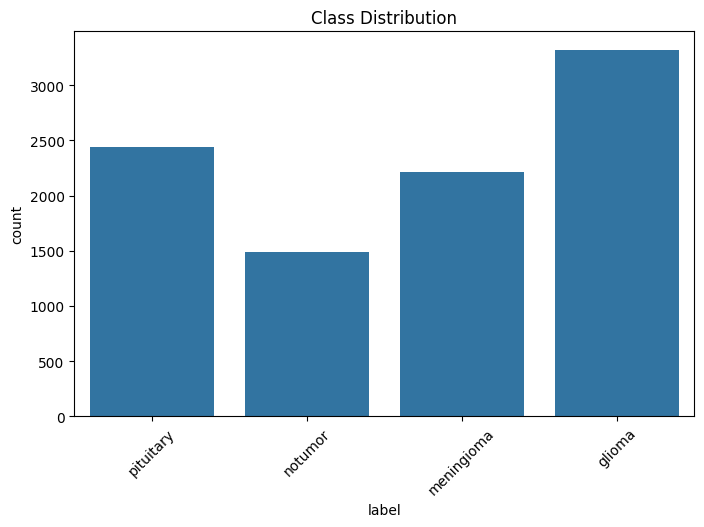

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

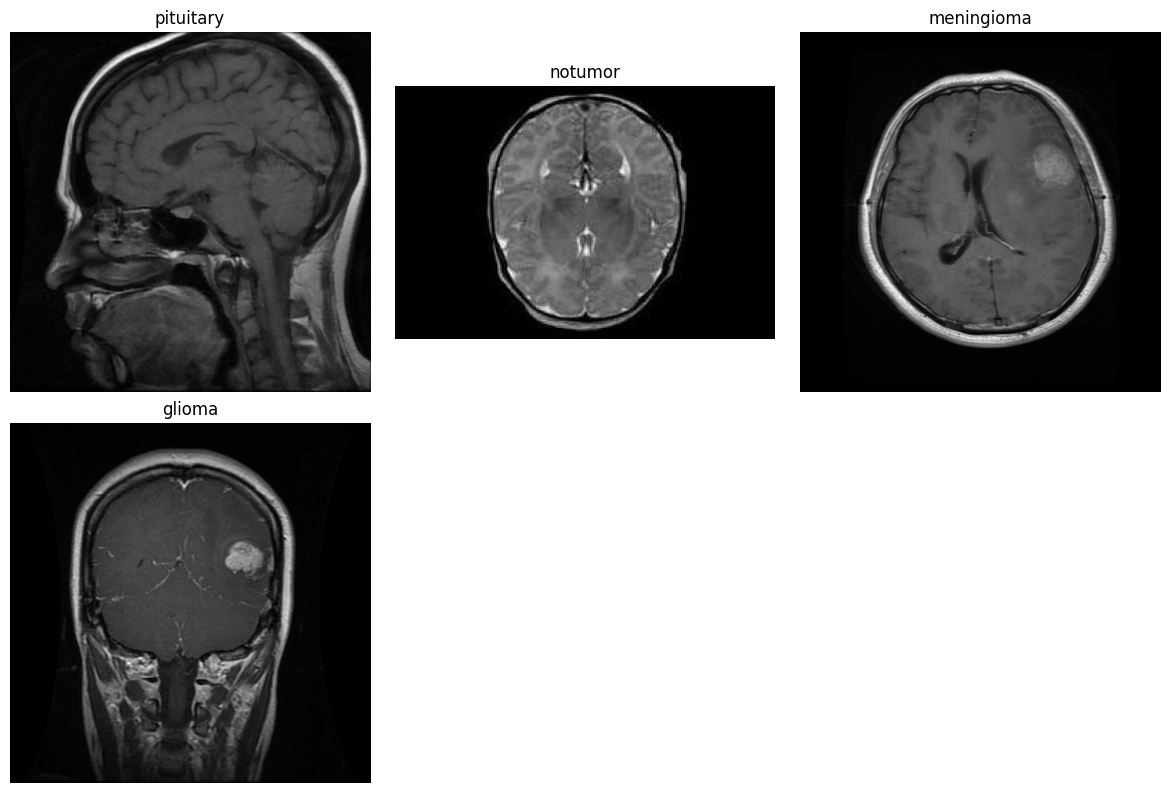

In [10]:
plt.figure(figsize=(12,8))

for i, label in enumerate(df['label'].unique()):
    img_path = df[df['label'] == label]['image_path'].iloc[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

100%|██████████| 9469/9469 [00:24<00:00, 392.72it/s]


             width       height
count  9469.000000  9469.000000
mean    404.505228   405.875594
std     145.084521   143.336720
min     150.000000   167.000000
25%     224.000000   224.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1375.000000  1446.000000


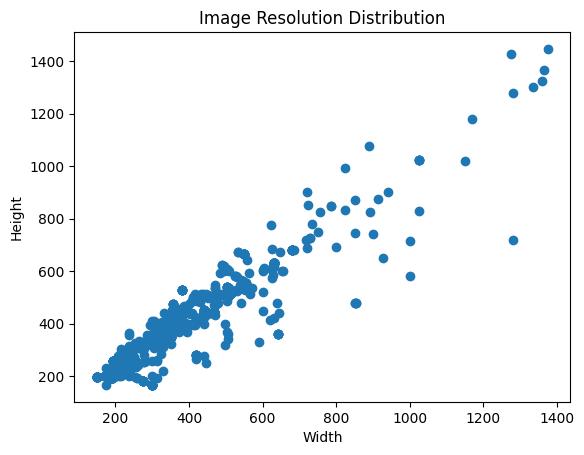

In [11]:
widths = []
heights = []

for path in tqdm(df['image_path']):
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

df['width'] = widths
df['height'] = heights

print(df[['width','height']].describe())

plt.scatter(widths, heights)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")
plt.show()

100%|██████████| 9469/9469 [00:27<00:00, 346.37it/s]


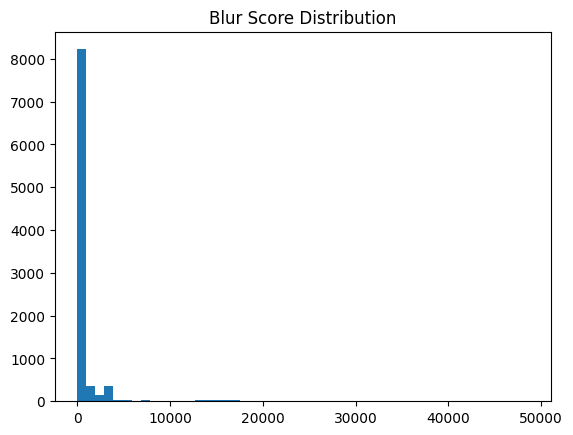

In [12]:
def blur_score(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = []

for path in tqdm(df['image_path']):
    img = cv2.imread(path)
    blur_scores.append(blur_score(img))

df['blur_score'] = blur_scores

plt.hist(blur_scores, bins=50)
plt.title("Blur Score Distribution")
plt.show()

100%|██████████| 9469/9469 [00:26<00:00, 358.11it/s]


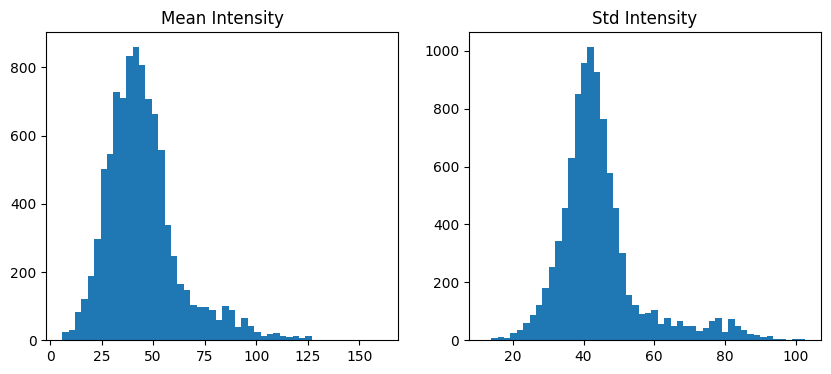

In [13]:
pixel_means = []
pixel_stds = []

for path in tqdm(df['image_path']):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    pixel_means.append(np.mean(img))
    pixel_stds.append(np.std(img))

df['mean_intensity'] = pixel_means
df['std_intensity'] = pixel_stds

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(pixel_means, bins=50)
plt.title("Mean Intensity")

plt.subplot(1,2,2)
plt.hist(pixel_stds, bins=50)
plt.title("Std Intensity")

plt.show()

100%|██████████| 9469/9469 [00:20<00:00, 469.54it/s]


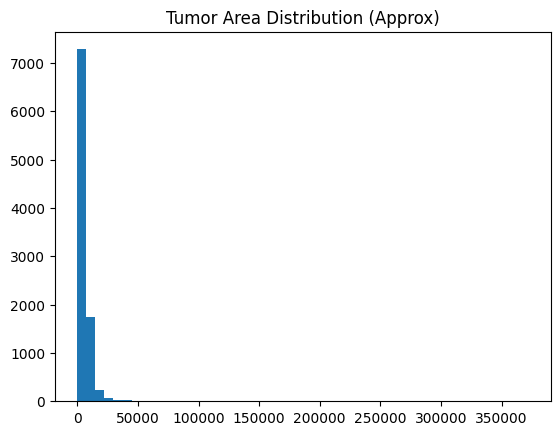

In [14]:
tumor_areas = []

for path in tqdm(df['image_path']):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    area = np.sum(thresh == 255)

    tumor_areas.append(area)

df['tumor_area'] = tumor_areas

plt.hist(tumor_areas, bins=50)
plt.title("Tumor Area Distribution (Approx)")
plt.show()

100%|██████████| 9469/9469 [00:19<00:00, 492.49it/s]


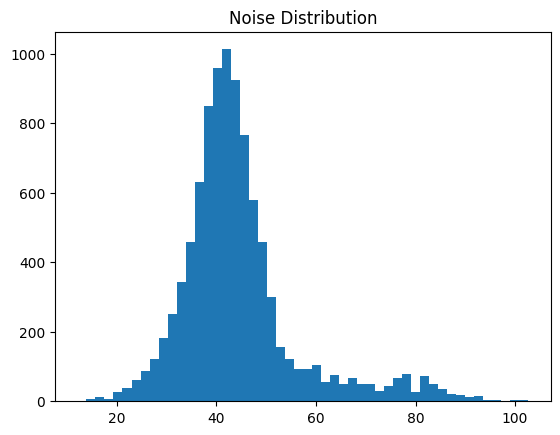

In [15]:
def noise_estimation(image):
    return np.std(image)

noise_levels = []

for path in tqdm(df['image_path']):
    img = cv2.imread(path, 0)
    noise_levels.append(noise_estimation(img))

df['noise'] = noise_levels

plt.hist(noise_levels, bins=50)
plt.title("Noise Distribution")
plt.show()

In [16]:
def get_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = []

for path in tqdm(df['image_path']):
    hashes.append(get_hash(path))

df['hash'] = hashes

duplicates = df[df.duplicated('hash')]
print("Duplicate Images:", len(duplicates))

100%|██████████| 9469/9469 [00:06<00:00, 1550.53it/s]

Duplicate Images: 0


In [18]:
print("\n===== EDA SUMMARY =====")
print("Total Images:", len(df))
print("Classes:", df['label'].unique())
print("\nClass Counts:\n", df['label'].value_counts())

print("\nResolution Range:")
print("Min:", df[['width','height']].min())
print("Max:", df[['width','height']].max())

print("\nBlur Score Avg:", df['blur_score'].mean())
print("Noise Avg:", df['noise'].mean())
print("Duplicates:", len(duplicates))


===== EDA SUMMARY =====
Total Images: 9469
Classes: ['pituitary' 'notumor' 'meningioma' 'glioma']

Class Counts:
 label
glioma        3321
pituitary     2440
meningioma    2216
notumor       1492
Name: count, dtype: int64

Resolution Range:
Min: width     150
height    167
dtype: int64
Max: width     1375
height    1446
dtype: int64

Blur Score Avg: 991.760750135861
Noise Avg: 44.43241830770774
Duplicates: 0
